# Software Defect Prediction Model
### Based on NASA JM1 Dataset & Radon Metrics

---

## Project Overview
This project implements a **Machine Learning model** designed to predict the probability of software defects within source code. 

The analysis is performed using **Static Code Metrics**, focusing on two industry-standard frameworks:
* **McCabe’s Cyclomatic Complexity:** Measures the logical complexity and control flow of the program ($v(g)$).
* **Halstead’s Software Science:** Measures computational complexity based on operators and operands (Volume, Effort, Difficulty).

**Goal:** To provide an automated risk assessment for code modules, allowing developers and AI agents to prioritize testing and code reviews.

## 1. Environment Setup and Libraries Injection
In this section, we import the essential Python libraries required for data manipulation, visualization, and machine learning. 
* **Pandas & NumPy:** For efficient data handling and numerical operations.
* **Matplotlib & Seaborn:** For exploratory data analysis and visual representation of data patterns.
* **Scikit-Learn:** For data preprocessing, scaling, and implementing the Logistic Regression model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 2. Data Acquisition
We load the **NASA JM1 dataset**, which contains over 10,000 instances of software modules. Each instance is described by multiple static code metrics. 
At this stage, we also perform an initial check for data integrity and identify missing values (NaN) to ensure the dataset is clean before proceeding to analysis.

In [2]:
train = pd.read_csv('data/archive/jm1.csv')

In [3]:
# Displaying the first few rows to verify successful loading
train.head()

,id,loc,v(g),ev(g),iv(g),n,v,l,d,i,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,2,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,...,1,1,1,1,1,1,1,1,1,True
2,3,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,...,51,10,8,1,17,36,112,86,13,True
3,4,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,...,129,29,28,2,17,135,329,271,5,True
4,5,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,...,28,1,6,0,11,16,76,50,7,True


** Use info and describe() on ad_data**

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10885 entries, 0 to 10884
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 10885 non-null  int64  
 1   loc                10885 non-null  float64
 2   v(g)               10885 non-null  float64
 3   ev(g)              10885 non-null  float64
 4   iv(g)              10885 non-null  float64
 5   n                  10885 non-null  float64
 6   v                  10885 non-null  float64
 7   l                  10885 non-null  float64
 8   d                  10885 non-null  float64
 9   i                  10885 non-null  float64
 10  e                  10885 non-null  float64
 11  b                  10885 non-null  float64
 12  t                  10885 non-null  float64
 13  lOCode             10885 non-null  int64  
 14  lOComment          10885 non-null  int64  
 15  lOBlank            10885 non-null  int64  
 16  locCodeAndComment  10885 non-null

## 3. Feature Selection: Aligning with Radon Metrics
To ensure the model is practical and compatible with our source code analysis tool (Radon), we narrow down the dataset to only include common metrics. 
This selection focuses on **McCabe's LOC and Cyclomatic Complexity**, alongside **Halstead's core metrics**.

In [5]:
# 1. הגדרת העמודות שאנחנו רוצים להשאיר (כולל ה-Target)
selected_columns = ['loc', 'v(g)', 'v', 'd', 'e', 'b', 'defects']

# 2. יצירת DataFrame חדש ומצומצם
train = train[selected_columns].copy()

# 3. המרת ה-Target למספרים (0 ו-1)
train['defects'] = train['defects'].astype(int)

# 4. וידוא אחרון שהכל תקין
print("--- Selected Features Info ---")
print(train.info())

--- Selected Features Info ---
<class 'pandas.DataFrame'>
RangeIndex: 10885 entries, 0 to 10884
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   loc      10885 non-null  float64
 1   v(g)     10885 non-null  float64
 2   v        10885 non-null  float64
 3   d        10885 non-null  float64
 4   e        10885 non-null  float64
 5   b        10885 non-null  float64
 6   defects  10885 non-null  int64  
dtypes: float64(6), int64(1)
memory usage: 595.4 KB
None


In [6]:
train.head()

,loc,v(g),v,d,e,b,defects
0,1.1,1.4,1.30,1.30,1.30,1.30,0
1,1.0,1.0,1.00,1.00,1.00,1.00,1
2,72.0,7.0,1134.13,20.31,23029.10,0.38,1
3,190.0,3.0,4348.76,17.06,74202.67,1.45,1
4,37.0,4.0,599.12,17.19,10297.30,0.20,1


# 4. Exploratory Data Analysis (EDA)

## 4.1 Statistical Profiling
In this step, we use `info()` and `describe()` to understand the data types, 
detect missing values, and observe the statistical distribution of our features.

In [7]:
# הצגת הסטטיסטיקה התיאורית
stats = train.describe()
display(stats)

# חישוב אחוז הבאגים בדאטה-סט
bug_percentage = train['defects'].mean() * 100
print(f"\nTarget Distribution: {bug_percentage:.2f}% of modules contain defects.")

,loc,v(g),v,d,e,b,defects
count,10885.000000,10885.000000,10885.000000,10885.000000,1.088500e+04,10885.000000,10885.000000
mean,42.016178,6.348590,673.758017,14.177237,3.683637e+04,0.224766,0.193477
std,76.593332,13.019695,1938.856196,18.709900,4.343678e+05,0.646408,0.395042
min,1.000000,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,11.000000,2.000000,48.430000,3.000000,1.619400e+02,0.020000,0.000000
50%,23.000000,3.000000,217.130000,9.090000,2.031020e+03,0.070000,0.000000
75%,46.000000,7.000000,621.480000,18.900000,1.141643e+04,0.210000,0.000000
max,3442.000000,470.000000,80843.080000,418.200000,3.107978e+07,26.950000,1.000000



Target Distribution: 19.35% of modules contain defects.


### Key Insights from Statistics:
1. **Scale Imbalance:** Features like `Effort (e)` have magnitudes millions of times larger than `Bugs (b)`. Standard scaling is mandatory.
2. **Skewed Data:** High maximum values in `loc` (3442) and `v(g)` (470) compared to their medians suggest the presence of extreme outliers.
3. **Class Imbalance:** Only ~19.4% of the modules are defective. We must account for this during model training using class weighting.

## 4.2 Correlation Analysis
Now, we visualize the relationships between metrics using a heatmap. 
This helps identify which code features are the most significant predictors for defects.

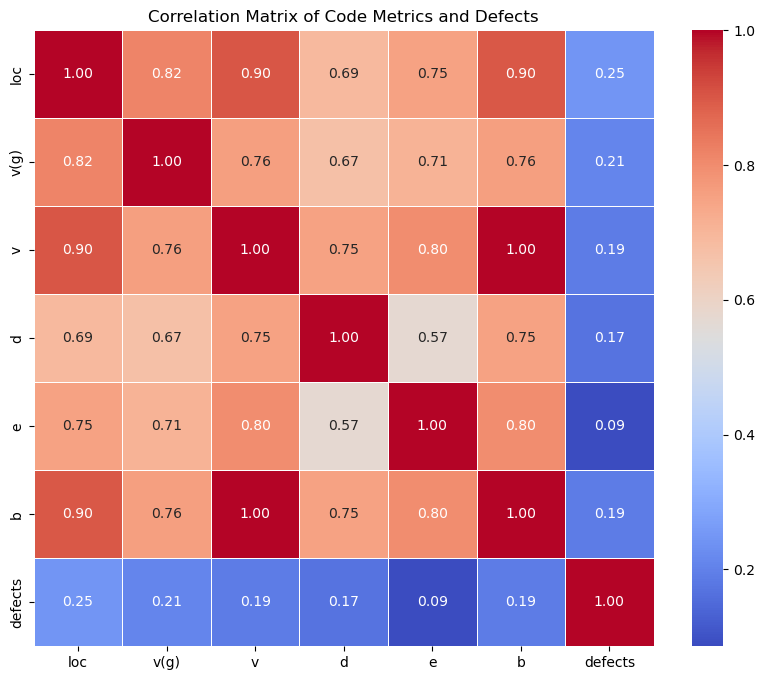

In [8]:
# חישוב מטריצת הקורלציה
plt.figure(figsize=(10, 8))
correlation_matrix = train.corr()

# יצירת ה-Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Code Metrics and Defects')
plt.show()

### Feature Redundancy Identified
The heatmap above reveals a correlation of **1.00** between `v` and `b`. 
Since `b` (Halstead's delivered bugs) is a linear derivative of `v` (Volume), keeping both would introduce **Multicollinearity**. 
To simplify the model, we will proceed with only the `v` feature.

In [9]:
train = train.drop(columns=['b'])

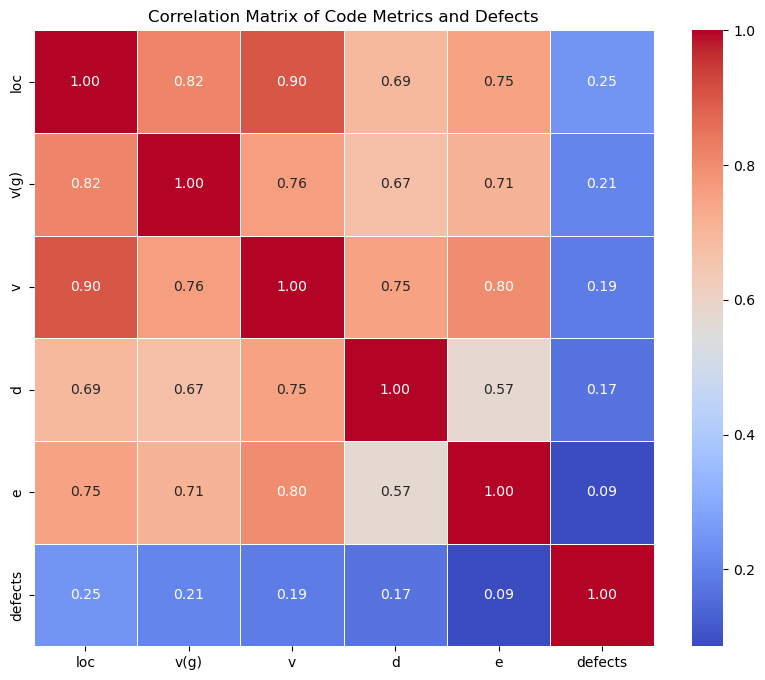

In [10]:
# חישוב מטריצת הקורלציה
plt.figure(figsize=(10, 8))
correlation_matrix = train.corr()

# יצירת ה-Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Code Metrics and Defects')
plt.show()

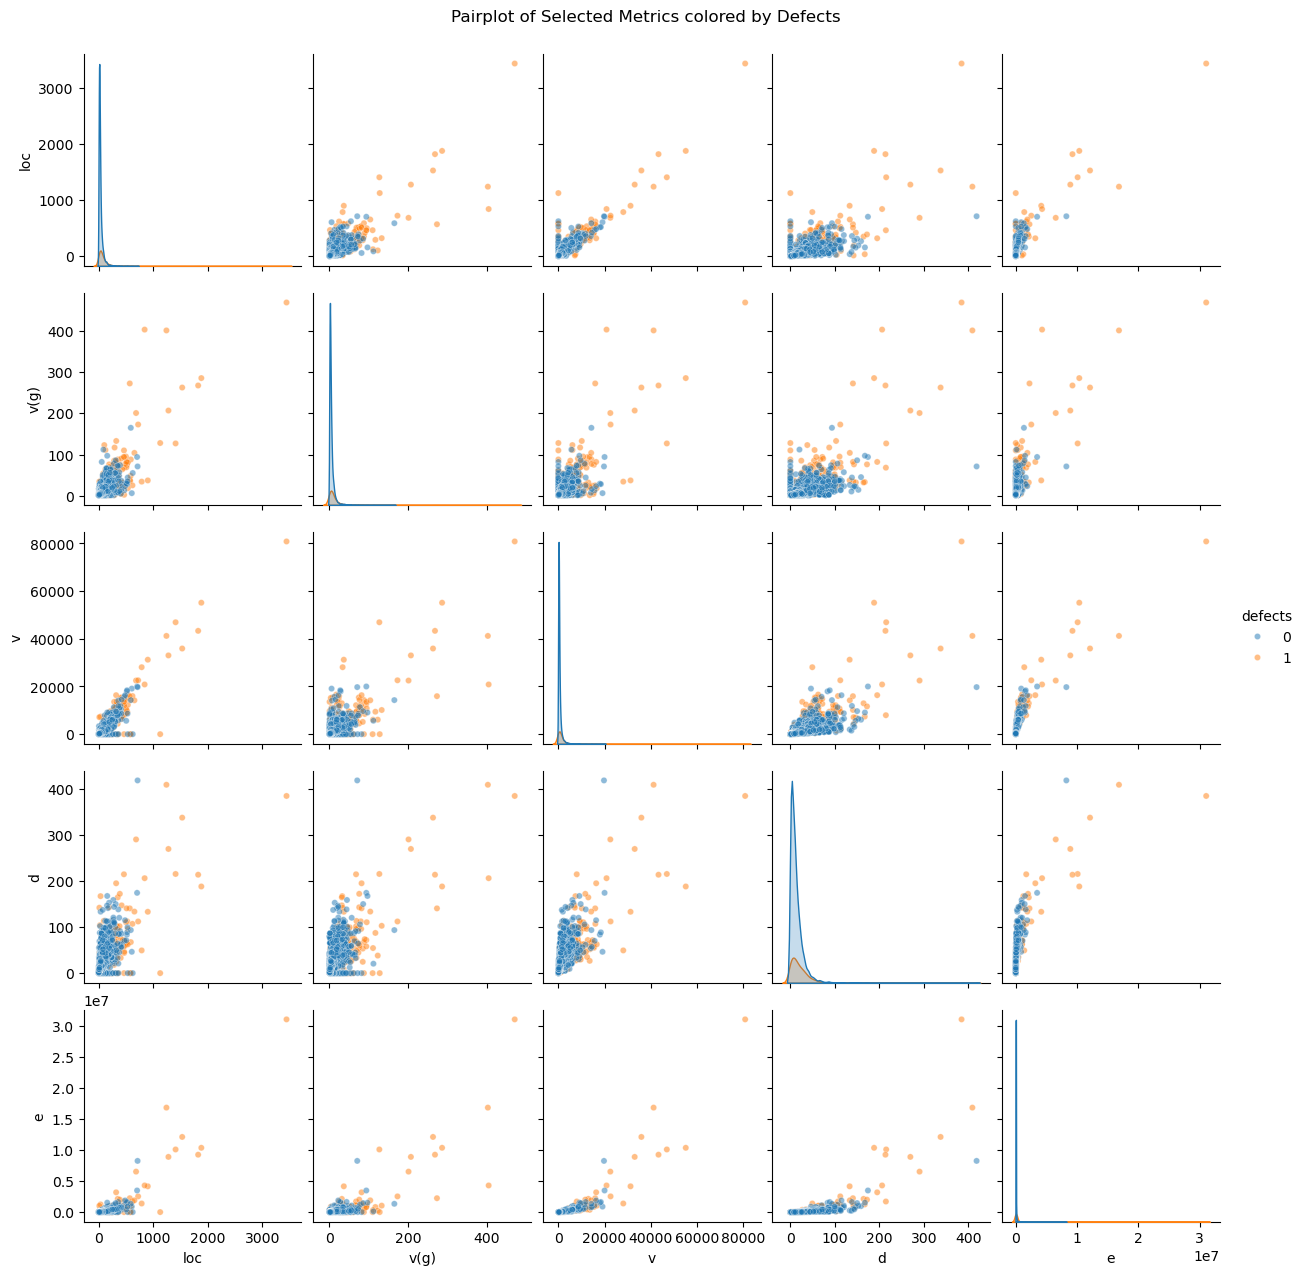

In [11]:
# יצירת Pairplot כדי לראות את הקשרים הויזואליים
# אנחנו משתמשים ב-hue כדי להבדיל בין מודולים עם ובלי באגים
sns.pairplot(train, hue='defects', diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Pairplot of Selected Metrics colored by Defects', y=1.02)
plt.show()

### Insights from Pairplot:
1. **Overlap in Simple Modules:** In low-complexity regions (bottom-left), defective and non-defective modules are highly interleaved, suggesting that static metrics alone aren't a "silver bullet" for small functions.
2. **Outlier Impact:** Extreme values in `loc` and `v(g)` are predominantly associated with defects (orange points), confirming that high complexity is a strong indicator of risk.
3. **Feature Correlation:** The linear patterns between `v`, `loc`, and `e` are visible, but the spread increases with scale, justifying the need for **StandardScaler** to stabilize the model's learning process.

# 5. Data Preprocessing
Before training our Logistic Regression model, we must prepare the data:
1. **Feature-Target Split:** Separating the independent variables (X) from the dependent variable (y).
2. **Train-Test Split:** Dividing the data to evaluate the model on unseen instances.
3. **Feature Scaling:** Normalizing the metrics to a standard scale (Mean=0, Std=1) to ensure fair weight distribution.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. הפרדה ל-X ו-y (זכור שהורדנו את b)
X = train.drop('defects', axis=1)
y = train['defects']

# 2. פיצול לסט אימון וסט בדיקה (20% לבדיקה)
# השתמשנו ב-stratify=y בגלל חוסר האיזון (19% באגים)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. נרמול הנתונים - קריטי בגלל ההבדלים שראינו ב-Describe
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 8708 samples
Testing set size: 2177 samples


In [13]:
# המרה של המערך המנורמל חזרה ל-DataFrame כדי שיהיה נוח להסתכל
X_train_scaled_train = pd.DataFrame(X_train_scaled, columns=X.columns)

# הצגת 5 השורות הראשונות
print("--- Data After Standard Scaling (X_train_scaled) ---")
display(X_train_scaled_train.head())

# הצגת סטטיסטיקה של הנתונים המנורמלים
print("\n--- Statistics After Scaling ---")
display(X_train_scaled_train.describe().round(2))

--- Data After Standard Scaling (X_train_scaled) ---


,loc,v(g),v,d,e
0,-0.106968,-0.101317,-0.161496,0.018342,-0.089797
1,1.014299,0.642485,0.879192,1.477563,0.183849
2,-0.331221,-0.018672,-0.185038,-0.205945,-0.096113
3,-0.555474,-0.431895,-0.375081,-0.763132,-0.107078
4,2.225266,2.708600,2.364776,0.904627,0.365941



--- Statistics After Scaling ---


,loc,v(g),v,d,e
count,8708.00,8708.00,8708.00,8708.00,8708.00
mean,0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-0.60,-0.43,-0.38,-0.76,-0.11
25%,-0.45,-0.35,-0.35,-0.60,-0.11
50%,-0.28,-0.27,-0.25,-0.27,-0.10
75%,0.07,0.06,-0.02,0.26,-0.07
max,27.52,32.87,31.38,21.95,54.43


### 5.4 Visualizing the Effect of Scaling
To verify the scaling process, we visualize the feature distributions using histograms. 

**Key Observations:**
* **Zero-Centered:** All features are now centered at a mean of **0**. Values to the left are below average, and values to the right are above average.
* **Uniform Variance:** Most data points now fall within the range of **-3 to +3**, ensuring that the model treats all features equally regardless of their original units (e.g., lines of code vs. Halstead volume).
* **Outlier Preservation:** While the majority of data is centered, the "long tails" (outliers) are preserved, which is important for identifying highly complex, bug-prone modules.

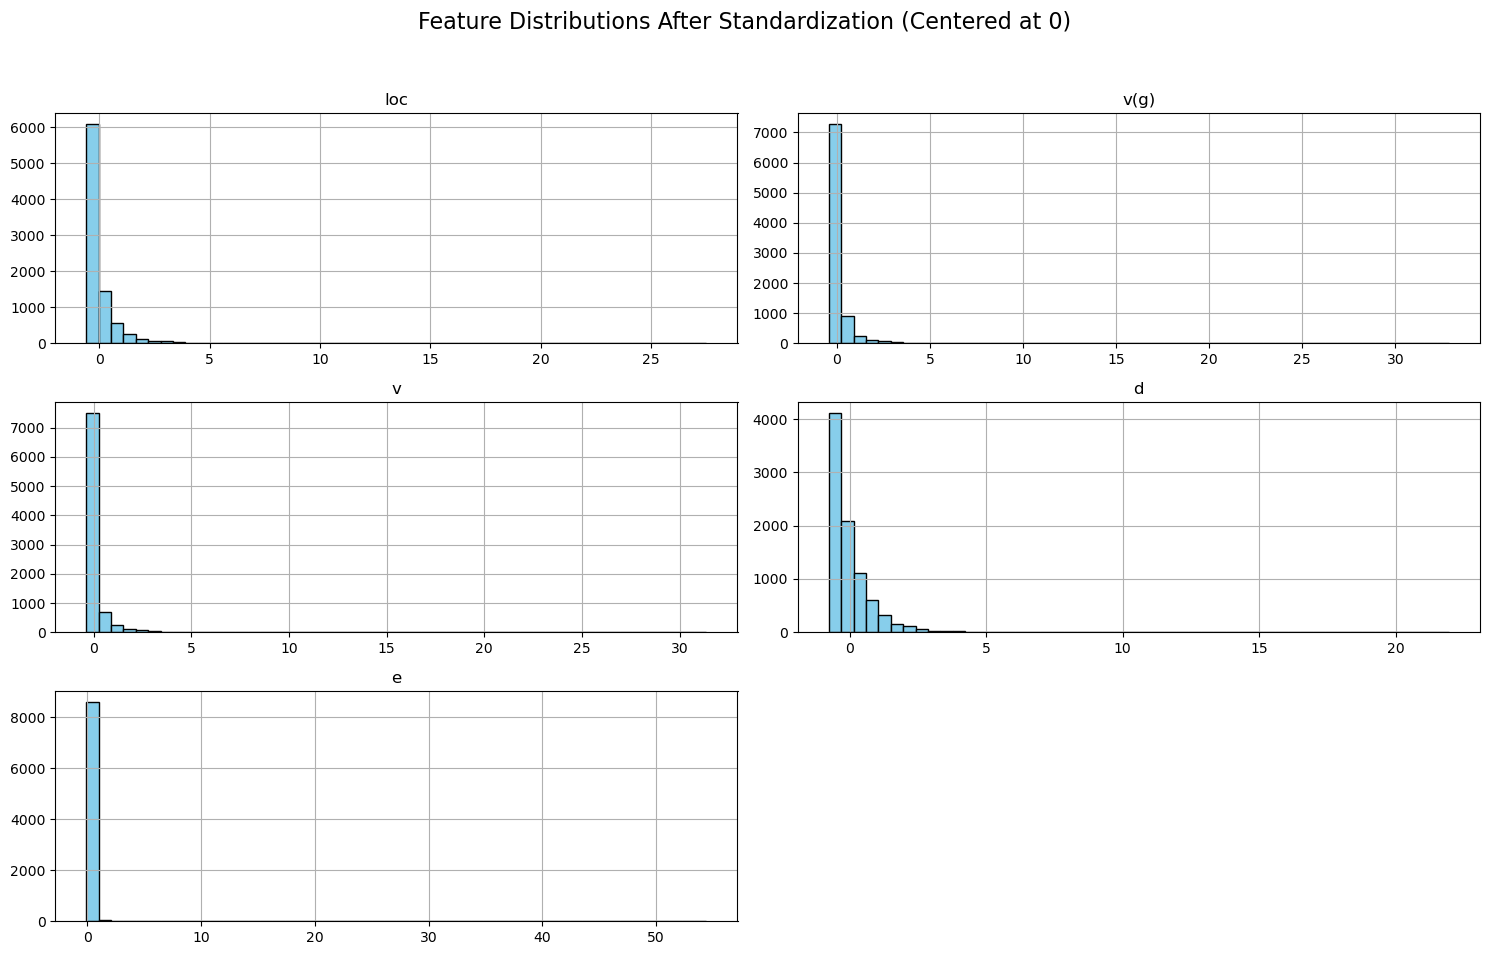

In [14]:
# היסטוגרמות של הנתונים המנורמלים
X_train_scaled_train.hist(bins=50, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Feature Distributions After Standardization (Centered at 0)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 6. Model Training & Evaluation

## 6.1 Algorithm Selection: Logistic Regression
We selected **Logistic Regression** as our primary classification model. It is a robust and efficient algorithm for binary classification tasks, offering high interpretability which is essential for understanding how code metrics influence defect probability.

## 6.2 Strategy for Imbalanced Data
As identified during the EDA phase, only **19.35%** of the modules contain defects. To prevent the model from being biased toward the majority class ("No Defects"), we implemented the following strategy:

* **Class Weighting**: We utilized the `class_weight='balanced'` parameter. This penalizes the model more heavily for missing a defect than for a false alarm.
* **Focus on Recall**: Our primary goal is to ensure the AI agent identifies as many potential bugs as possible. High **Recall** is prioritized over high Precision in this safety-critical context.

In [15]:
from sklearn.linear_model import LogisticRegression

# Initialize the model with balanced class weights
logmodel = LogisticRegression(class_weight='balanced', random_state=42)

# Fit the model to the scaled training data
logmodel.fit(X_train_scaled, y_train)

# Generate predictions on the scaled test set
predictions = logmodel.predict(X_test_scaled)

print("Logistic Regression Model trained and predictions generated.")

Logistic Regression Model trained and predictions generated.


## 7. Performance Analysis

To evaluate the model's effectiveness, we use a **Confusion Matrix** and a **Classification Report**. Given the class imbalance, we look beyond simple Accuracy and focus on the following metrics:

### Key Metrics Explained:
1.  **Recall (Sensitivity)**: Out of all actual defects, how many did the model catch? (Crucial for bug detection).
2.  **Precision**: When the model predicts a defect, how often is it correct?
3.  **F1-Score**: The harmonic mean of Precision and Recall, providing a balanced view of the model's performance.

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

# Confusion Matrix
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, predictions))

# Full Report
print("\n--- Classification Report ---")
print(classification_report(y_test, predictions))

--- Confusion Matrix ---
[[1377  379]
 [ 220  201]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.78      0.82      1756
           1       0.35      0.48      0.40       421

    accuracy                           0.72      2177
   macro avg       0.60      0.63      0.61      2177
weighted avg       0.76      0.72      0.74      2177



## 8. Final Results & Interpretation

### 8.1 Performance Summary
Our Logistic Regression model, optimized with balanced class weights, yielded the following results for defect detection (Class 1):
* **Recall: 0.48** – The model successfully identified nearly half of all actual defective modules.
* **Precision: 0.35** – Out of all predicted defects, 35% were accurate, while the rest were false positives.
* **F1-Score: 0.40** – Represents the balance between our ability to catch bugs and the frequency of false alarms.

### 8.2 Conclusion
The model demonstrates a clear ability to distinguish between complex, bug-prone code and simple modules, significantly outperforming a random guess. However, the moderate recall suggests that code metrics (loc, v(g), etc.) provide a strong signal but are not the only factors contributing to software defects. 

**Next Steps for Improvement:**
1. **Feature Engineering**: Incorporating more advanced metrics or historical data.
2. **Advanced Algorithms**: Testing non-linear models like Random Forest or XGBoost.
3. **Threshold Tuning**: Adjusting the probability threshold to further increase Recall based on project risk tolerance.

# 9. Model Upgrade: Random Forest Classifier

## 9.1 Why Random Forest?
After evaluating the **Logistic Regression** baseline, we observed that while it captures general trends, it struggles with the non-linear distribution and high overlap seen in our `pairplot`. 

To achieve better performance, we transition to **Random Forest**, an ensemble learning method that offers several advantages for this specific problem:

* **Non-Linear Decision Boundaries**: Unlike Logistic Regression, Random Forest does not assume a linear relationship. It uses multiple decision trees to "capture" complex clusters of defects in the data.
* **Feature Interaction**: It automatically identifies interactions between metrics (e.g., how high `loc` combined with high `v(g)` affects the bug probability) without needing manual feature engineering.
* **Robustness to Outliers**: Since it is based on decision trees, it is less sensitive to the extreme outliers we observed in the `Effort (e)` and `Volume (v)` metrics.

## 9.2 Handling Class Imbalance
Similar to our previous approach, we will utilize the `class_weight='balanced'` parameter to ensure the model remains sensitive to the minority class (Defects).

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize Random Forest with balanced weights
rf_model = RandomForestClassifier(n_estimators=100)

# 2. Train the model
rf_model.fit(X_train_scaled, y_train)

# 3. Predict
rf_predictions = rf_model.predict(X_test_scaled)

# 4. Evaluate
print("--- Random Forest Confusion Matrix ---")
print(confusion_matrix(y_test, rf_predictions))
print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, rf_predictions))

--- Random Forest Confusion Matrix ---
[[1628  128]
 [ 320  101]]

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      1756
           1       0.44      0.24      0.31       421

    accuracy                           0.79      2177
   macro avg       0.64      0.58      0.59      2177
weighted avg       0.76      0.79      0.77      2177



### 9.3 Dataset Capacity for Ensemble Learning
Our split resulting in **8,708 training samples** provides an excellent foundation for Random Forest. 
* **Statistical Power**: With over 8,000 samples, the algorithm can generate a diverse set of 100+ decision trees, ensuring that the final "majority vote" is statistically significant.
* **Validation Robustness**: The **2,177 testing samples** are sufficient to provide a reliable estimate of how the model will perform on real-world code analyzed by our AI agent.

In [22]:
# קבלת ההסתברויות (Probabilities)
# print("--- X_test_scaled ---", X_test_scaled)
# rf_probs = rf_model.predict_proba(X_test_scaled)
# print("--- rf_probs ---", rf_probs)

# קבלת ההסתברויות (Probabilities)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

# הגדרת סף נמוך יותר - מספיק ש-30% מהעצים יחשדו בבאג
custom_threshold = 0.3
rf_final_preds = (rf_probs >= custom_threshold).astype(int)

print("--- Random Forest with 0.3 Threshold ---")
print(classification_report(y_test, rf_final_preds))

--- Random Forest with 0.3 Threshold ---
              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1756
           1       0.35      0.48      0.40       421

    accuracy                           0.73      2177
   macro avg       0.61      0.63      0.61      2177
weighted avg       0.76      0.73      0.74      2177



In [25]:
# יצירת DataFrame שמשלב את הנתונים המקוריים עם התוצאות
results_df = X_test.copy()
results_df['actual_defect'] = y_test
results_df['predicted_defect'] = predictions # כאן נשתמש בחיזויים של הלוגיסטית

# סינון: רק מקרים שבהם באמת יש באג
defects_only = results_df[results_df['actual_defect'] == 1]

# הצגת 10 השורות הראשונות של באגים
print("Samples of actual defects in the test set:")
print(defects_only.head(10))

# בונוס: בוא נראה את הממוצעים של הבאגים לעומת הממוצעים של הקוד התקין
print("\n--- Mean values comparison ---")
print(results_df.groupby('actual_defect').mean())

Samples of actual defects in the test set:
        loc  v(g)        v      d          e  actual_defect  predicted_defect
936    15.0   3.0   213.62  10.50    2242.98              1                 0
1528   41.0   2.0   342.35   9.12    3121.44              1                 0
75     22.0   1.0   508.77  12.06    6135.20              1                 0
271    31.0  12.0     0.00   0.00       0.00              1                 0
2055  132.0  14.0  2929.01  29.93   87650.65              1                 1
63    171.0  16.0  4230.99  34.25  144911.31              1                 1
713    15.0   3.0   197.65   6.46    1277.15              1                 0
1284   20.0   3.0   166.91   8.80    1468.79              1                 0
65      8.0   1.0    51.89   2.92     151.35              1                 0
366    10.0   2.0   260.06  12.09    3144.31              1                 0

--- Mean values comparison ---
                     loc       v(g)            v          d        